<a href="https://colab.research.google.com/github/umaruniversity750-hash/Student-Performance-Analytics-System/blob/main/student_profermance_systeam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [6]:
df = pd.read_csv('/content/stu.csv')

In [8]:
df.head()

,Serial_No,Roll_No,Student_Name,SGPA,CGPA,Semester_Result,Overall_Result
0,1,2560047001,ANCHAL PANDEY,5.25,6.00,PCP,PCP
1,2,2560047002,UMAR NASEEM,4.54,5.69,PCP,PCP
2,3,2560047004,EKLAVYA SHARMA,6.79,7.08,PASS,PASS
3,4,2560047005,VINAY KUMAR,3.67,4.39,PCP,PCP
4,5,2560047006,HARSHIT OJHA,5.79,6.78,PASS,PASS


In [52]:
df=subject = ["physics, C programming, Web development, Workshop, Enviormental science,"]

In [32]:
def calculate_grade(marks):
  if average >= 90:
    return "A+"
  elif average >= 80:
        return "A"
  elif average >= 70:
        return "B"
  elif average >= 60:
        return "C"
  elif average >= 50:
        return "D"
  elif average >= 33:
        return "E"
  else:
        return "F"



In [59]:
grade =65
grade=calculate_grade(average)
print("Average Marks:",average)
print("Grade:",grade)

Average Marks: 65
Grade: C


In [66]:
# Redefining the function to use the parameter 'marks' instead of 'average'
def calculate_grade(marks):
    if marks >= 90:
        return "A+"
    elif marks >= 80:
        return "A"
    elif marks >= 70:
        return "B"
    elif marks >= 60:
        return "C"
    elif marks >= 50:
        return "D"
    elif marks >= 33:
        return "E"
    else:
        return "F"

# Create 'Average_Marks' based on CGPA (on a 100-point scale)
df["Average_Marks"] = df["CGPA"] * 10

# Apply the corrected function
df["Grade"] = df["Average_Marks"].apply(calculate_grade)

# Overall statistics
print("===== OVERALL STATISTICS =====")
print("Total Students:", len(df))
print("Average Student Marks:", round(df["Average_Marks"].mean(), 2))
print("Highest Average:", round(df["Average_Marks"].max(), 2))
print("Lowest Average:", round(df["Average_Marks"].min(), 2))

# Pass/fail statistics using actual column 'Overall_Result'
pass_count = (df["Overall_Result"] == "PASS").sum()
fail_count = (df["Overall_Result"] == "PCP").sum()  # Assuming PCP represents failing or needing improvement

print("\n===== PASS/FAIL STATISTICS =====")
print("Pass Students:", pass_count)
print("PCP Students:", fail_count)

pass_percentage = (
    pass_count / len(df) * 100 if len(df) > 0 else 0
)
print("Pass Percentage:", round(pass_percentage, 2), "%")

# Grade distribution
print("\n===== GRADE DISTRIBUTION =====")
print(df["Grade"].value_counts().sort_index())

===== OVERALL STATISTICS =====
Total Students: 39
Average Student Marks: 60.47
Highest Average: 85.3
Lowest Average: 31.4

===== PASS/FAIL STATISTICS =====
Pass Students: 19
PCP Students: 20
Pass Percentage: 48.72 %

===== GRADE DISTRIBUTION =====
Grade
A     4
B     7
C     9
D     8
E    10
F     1
Name: count, dtype: int64


In [68]:
df = pd.read_csv("stu.csv")
print(df.columns.tolist())

['Serial_No', 'Roll_No', 'Student_Name', 'SGPA', 'CGPA', 'Semester_Result', 'Overall_Result']


In [76]:
total_students = len(df)
class_average = df["Average_Marks"].mean()
highest_average = df["Average_Marks"].max()
lowest_average = df["Average_Marks"].min()

pass_count = (df["Result"] == "Pass").sum()
fail_count = (df["Result"] == "Fail").sum()
pass_percentage = pass_count / total_students * 100

subject_averages = df[subjects].mean()
top_students = df.nlargest(5, "Average_Marks")

print("=" * 55)
print(" STUDENT PERFORMANCE ANALYTICS SYSTEM")
print("=" * 55)
print("Total Students:", total_students)
print("Class Average:", round(class_average, 2))
print("Highest Average:", round(highest_average, 2))
print("Lowest Average:", round(lowest_average, 2))
print("Pass Students:", pass_count)
print("Fail Students:", fail_count)
print("Pass Percentage:", round(pass_percentage, 2), "%")

print("\nTOP 5 STUDENTS")
print(top_students[
    ["Student_ID", "Name", "Average_Marks", "Grade"]
].round(2).to_string(index=False))

 STUDENT PERFORMANCE ANALYTICS SYSTEM
Total Students: 20
Class Average: 68.32
Highest Average: 94.67
Lowest Average: 30.0
Pass Students: 18
Fail Students: 2
Pass Percentage: 90.0 %

TOP 5 STUDENTS
 Student_ID   Name  Average_Marks Grade
        108   Zoya          94.67    A+
        102   Sara          91.67    A+
        114 Ananya          91.33    A+
        118   Riya          87.33     A
        110   Isha          86.00     A


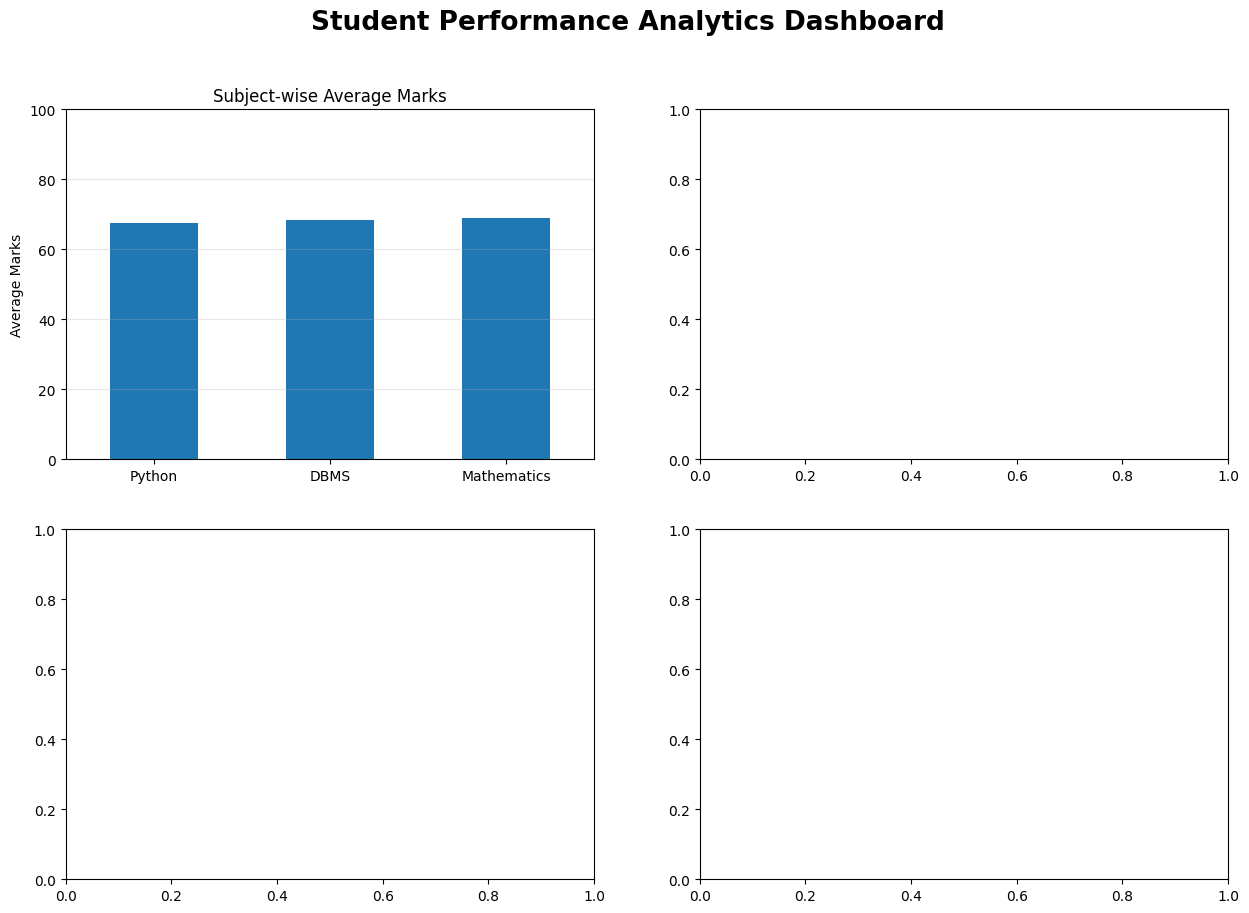

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    "Student Performance Analytics Dashboard",
    fontsize=19,
    fontweight="bold"
)

# Chart 1: Subject-wise Average
subject_averages.plot(
    kind="bar",
    ax=axes[0, 0],
    title="Subject-wise Average Marks",
    rot=0
)
axes[0, 0].set_ylabel("Average Marks")
axes[0, 0].set_ylim(0, 100)
axes[0, 0].grid(axis="y", alpha=0.3)


In [79]:
df["Grade"].value_counts().sort_index().plot(
    kind="pie",
    ax=axes[0, 1],
    autopct="%1.1f%%",
    title="Grade Distribution",
    ylabel=""
)

# Chart 3: Pass / Fail
pd.Series({
    "Pass": pass_count,
    "Fail": fail_count
}).plot(
    kind="bar",
    ax=axes[1, 0],
    title="Pass / Fail Count",
    rot=0
)
axes[1, 0].set_ylabel("Number of Students")
axes[1, 0].grid(axis="y", alpha=0.3)

# Chart 4: Top 5 Students
axes[1, 1].bar(
    top_students["Name"],
    top_students["Average_Marks"]
)
axes[1, 1].set_title("Top 5 Performing Students")
axes[1, 1].set_ylabel("Average Marks")
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [80]:
df.to_csv("student_performance_report.csv", index=False)
top_students.to_csv("top_students.csv", index=False)

print("\nReports saved successfully!")


Reports saved successfully!


In [81]:
display(df)

,Student_ID,Name,Department,Python,DBMS,Mathematics,Attendance,Total_Marks,Average_Marks,Grade,Result
0,101,Aman,MCA,85,80,90,95,255,85.000000,A,Pass
1,102,Sara,MCA,92,88,95,98,275,91.666667,A+,Pass
2,103,Rahul,BCA,45,50,40,75,135,45.000000,E,Pass
3,104,Priya,MCA,78,72,81,90,231,77.000000,B,Pass
4,105,Arman,BCA,30,35,25,60,90,30.000000,F,Fail
5,106,Neha,MCA,66,70,75,85,211,70.333333,B,Pass
6,107,Vikas,BCA,55,60,58,80,173,57.666667,D,Pass
7,108,Zoya,MCA,95,91,98,99,284,94.666667,A+,Pass
8,109,Rohan,BCA,72,68,74,88,214,71.333333,B,Pass
9,110,Isha,MCA,88,84,86,93,258,86.000000,A,Pass
